## t-SNE визуализация рок-поджанров FMA с HDBSCAN кластеризацией

Ноутбук:
1. Определяет поджанры Rock в датасете FMA через `genres.csv` / `tracks.csv`.
2. Находит соответствующие аудиофайлы (mp3) в `data/fma_small/`.
3. Вычисляет CQT-хрома тактовые эмбеддинги (`cqt_chroma_bar_embeddings`).
4. Строит t-SNE: все поджанры на одном графике разными цветами.
5. Запускает HDBSCAN и подписывает кластеры.

In [1]:
import os
import sys
import ast
import glob
from pathlib import Path

# Определение корня проекта
try:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython is not None:
        notebook_name = ipython.user_ns.get('__vsc_ipynb_file__') or ipython.user_ns.get('__file__')
        if notebook_name:
            notebook_path = Path(notebook_name).resolve()
            if 'notebooks' in str(notebook_path):
                project_root = notebook_path.parent.parent
            else:
                project_root = notebook_path.parent
        else:
            cwd = Path.cwd().resolve()
            if (cwd / 'notebooks').exists() and (cwd / 'src').exists():
                project_root = cwd
            elif 'notebooks' in str(cwd):
                project_root = cwd.parent
            else:
                project_root = cwd
    else:
        raise AttributeError("Not in IPython")
except:
    cwd = Path.cwd().resolve()
    if (cwd / 'notebooks').exists() and (cwd / 'src').exists():
        project_root = cwd
    elif 'notebooks' in str(cwd):
        project_root = cwd.parent
    else:
        current = cwd
        while current != current.parent:
            if (current / 'notebooks').exists() and (current / 'src').exists():
                project_root = current
                break
            current = current.parent
        else:
            project_root = cwd

sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

print(f"✓ Корень проекта: {project_root}")
print(f"✓ Текущая рабочая директория: {Path.cwd()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.topology_methods import cqt_chroma_bar_embeddings
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import hdbscan

plt.rcParams.update({'font.size': 12})
plt.rcParams['figure.dpi'] = 120

✓ Корень проекта: /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork
✓ Текущая рабочая директория: /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/notebooks_tda


## 1. Загрузка FMA-метаданных и определение рок-поджанров

In [2]:
metadata_dir = project_root / 'data' / 'fma_metadata'
audio_dir    = project_root / 'data' / 'fma_small'

# Жанры
genres_df = pd.read_csv(metadata_dir / 'genres.csv')
# Треки (мультиуровневый заголовок)
tracks_df = pd.read_csv(metadata_dir / 'tracks.csv', header=[0, 1], index_col=0)

# Rock и его поджанры
rock_genre_id = genres_df.loc[genres_df['title'] == 'Rock', 'genre_id'].values[0]
rock_subgenres = genres_df[genres_df['parent'] == rock_genre_id][['genre_id', 'title', '#tracks']]
rock_subgenres = rock_subgenres.sort_values('#tracks', ascending=False)

subgenre_id_to_name = dict(zip(rock_subgenres['genre_id'], rock_subgenres['title']))
subgenre_ids = set(rock_subgenres['genre_id'].tolist())

print(f"Rock genre_id = {rock_genre_id}")
print(f"\nПоджанры Rock ({len(rock_subgenres)}):")
for _, row in rock_subgenres.iterrows():
    print(f"  {row['title']:20s}  (id={row['genre_id']:4d}, #tracks={row['#tracks']:5d})")

Rock genre_id = 12

Поджанры Rock (15):
  Punk                  (id=  25, #tracks= 9261)
  Lo-Fi                 (id=  27, #tracks= 6041)
  Indie-Rock            (id=  66, #tracks= 5432)
  Garage                (id=  85, #tracks= 3548)
  Psych-Rock            (id=  58, #tracks= 2502)
  Loud-Rock             (id=  45, #tracks= 2469)
  Industrial            (id=  70, #tracks= 2230)
  Post-Rock             (id=  26, #tracks= 1952)
  Metal                 (id=  31, #tracks= 1498)
  Progressive           (id=  98, #tracks=  795)
  Shoegaze              (id= 359, #tracks=  762)
  Krautrock             (id=  36, #tracks=  688)
  New Wave              (id=  88, #tracks=  517)
  Goth                  (id= 314, #tracks=  482)
  Rock Opera            (id= 440, #tracks=  116)


In [3]:
# Определяем рок-поджанр каждого трека
track_genres_col = tracks_df[('track', 'genres')]

def find_rock_subgenre(genres_str):
    """Возвращает id рок-поджанра для трека, или None."""
    try:
        gids = ast.literal_eval(genres_str)
    except:
        return None
    for gid in gids:
        if gid in subgenre_ids:
            return gid
    return None

track_subgenre = track_genres_col.apply(find_rock_subgenre)
rock_track_ids = track_subgenre.dropna().index.tolist()
print(f"Треков с рок-поджанром в метаданных: {len(rock_track_ids)}")

Треков с рок-поджанром в метаданных: 25034


In [4]:
def track_id_to_path(tid):
    """Превращает track_id FMA в путь к MP3-файлу."""
    tid_str = f"{int(tid):06d}"
    return audio_dir / tid_str[:3] / f"{tid_str}.mp3"

# Оставляем только треки, файлы которых реально существуют на диске
existing_tracks = []
for tid in rock_track_ids:
    p = track_id_to_path(tid)
    if p.exists():
        existing_tracks.append(tid)

print(f"Аудиофайлов на диске: {len(existing_tracks)} из {len(rock_track_ids)}")

Аудиофайлов на диске: 765 из 25034


## 2. Параметры CQT-хрома эмбеддингов и t-SNE / HDBSCAN

In [5]:
# Параметры CQT-баровых эмбеддингов (как в topology_visualization.ipynb)
bins_per_octave = 36
hop_len = 2048
n_octaves = 7
beats_per_bar = 4
aggregation = "mean"
use_auto_tempo = True
bpm = None

# Параметры t-SNE
tsne_perplexity = 50
tsne_iterations = 1000

# Параметры HDBSCAN
min_cluster_size = 30
min_samples = 5

## 3. Вычисление CQT-хрома тактовых эмбеддингов для всех рок-поджанров

In [6]:
all_bars = []       # список numpy-массивов (n_bars_i, n_features)
bar_labels = []     # название поджанра для каждого такта

total = len(existing_tracks)
for idx, tid in enumerate(existing_tracks):
    fpath = str(track_id_to_path(tid))
    subgenre_name = subgenre_id_to_name[int(track_subgenre.loc[tid])]

    if (idx + 1) % 50 == 0 or idx == 0:
        print(f"[{idx+1}/{total}]  {subgenre_name:20s}  {fpath}")

    try:
        bars = cqt_chroma_bar_embeddings(
            file_path=fpath,
            bins_per_octave=bins_per_octave,
            hop_len=hop_len,
            n_octaves=n_octaves,
            beats_per_bar=beats_per_bar,
            aggregation=aggregation,
            use_auto_tempo=use_auto_tempo,
            bpm=bpm,
        )
        if bars.size == 0:
            continue
        all_bars.append(bars)
        bar_labels.extend([subgenre_name] * bars.shape[0])
    except Exception as e:
        print(f"  ⚠ Ошибка при обработке {fpath}: {e}")

X = np.vstack(all_bars).astype(np.float32)
labels_genre_name = np.array(bar_labels)

print(f"\nИтого тактов: {X.shape[0]}, размерность: {X.shape[1]}")
unique_names, counts = np.unique(labels_genre_name, return_counts=True)
for n, c in sorted(zip(unique_names, counts), key=lambda x: -x[1]):
    print(f"  {n:20s}: {c:6d} тактов")

[1/765]  Lo-Fi                 /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/000/000182.mp3
  ⚠ Ошибка при обработке /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/010/010675.mp3: float division by zero
[50/765]  Indie-Rock            /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/021/021859.mp3
[100/765]  Psych-Rock            /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/042/042761.mp3
[150/765]  Post-Rock             /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/055/055715.mp3
[200/765]  Lo-Fi                 /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/066/066535.mp3
[250/765]  Psych-Rock            /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/074/074669.mp3
[300/765]  Punk                  /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/090/090695.mp3
[350/765]  Garage                /Users/mverzhbitskiy/Documents/Git

[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...


[450/765]  Metal                 /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/112/112314.mp3
[500/765]  Post-Rock             /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/114/114415.mp3
[550/765]  Garage                /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/122/122399.mp3
[600/765]  Indie-Rock            /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/126/126672.mp3
[650/765]  Psych-Rock            /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/133/133729.mp3
[700/765]  New Wave              /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/138/138318.mp3
[750/765]  Indie-Rock            /Users/mverzhbitskiy/Documents/GitHub/3rdCourseWork/data/fma_small/146/146478.mp3

Итого тактов: 12105, размерность: 12
  Punk                :   2687 тактов
  Indie-Rock          :   2617 тактов
  Metal               :   1391 тактов
  Post-Rock           :   1351 тактов
  Psy

## 4. t-SNE проекция

In [7]:
# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_samples = X_scaled.shape[0]
perplexity = min(tsne_perplexity, max(5, n_samples - 1))
print(f"Запуск t-SNE (n={n_samples}, perplexity={perplexity}, iter={tsne_iterations})...")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    max_iter=tsne_iterations,
    random_state=42,
    verbose=1,
)
X_2d = tsne.fit_transform(X_scaled)
print("t-SNE завершён.")

Запуск t-SNE (n=12105, perplexity=50, iter=1000)...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 12105 samples in 0.003s...
[t-SNE] Computed neighbors for 12105 samples in 0.839s...
[t-SNE] Computed conditional probabilities for sample 1000 / 12105
[t-SNE] Computed conditional probabilities for sample 2000 / 12105
[t-SNE] Computed conditional probabilities for sample 3000 / 12105
[t-SNE] Computed conditional probabilities for sample 4000 / 12105
[t-SNE] Computed conditional probabilities for sample 5000 / 12105
[t-SNE] Computed conditional probabilities for sample 6000 / 12105
[t-SNE] Computed conditional probabilities for sample 7000 / 12105
[t-SNE] Computed conditional probabilities for sample 8000 / 12105
[t-SNE] Computed conditional probabilities for sample 9000 / 12105
[t-SNE] Computed conditional probabilities for sample 10000 / 12105
[t-SNE] Computed conditional probabilities for sample 11000 / 12105
[t-SNE] Computed conditional probabilities for sample 12000 / 121

## 5. HDBSCAN кластеризация

In [8]:
print(f"Запуск HDBSCAN (min_cluster_size={min_cluster_size}, min_samples={min_samples})...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
)
cluster_labels = clusterer.fit_predict(X_scaled)

unique_clusters = np.unique(cluster_labels)
n_clusters = len(unique_clusters[unique_clusters >= 0])
n_noise = np.sum(cluster_labels == -1)

print(f"Найдено кластеров: {n_clusters}")
print(f"Шумовых точек: {n_noise} ({100*n_noise/len(cluster_labels):.1f}%)")

# Таблица: жанры × кластеры
ct = pd.crosstab(
    pd.Series(cluster_labels, name='cluster'),
    pd.Series(labels_genre_name, name='subgenre'),
)
print(f"\nРаспределение жанров по кластерам:")
print(ct.to_string())

Запуск HDBSCAN (min_cluster_size=30, min_samples=5)...
Найдено кластеров: 2
Шумовых точек: 11577 (95.6%)

Распределение жанров по кластерам:
subgenre  Garage  Goth  Indie-Rock  Industrial  Krautrock  Lo-Fi  Loud-Rock  Metal  New Wave  Post-Rock  Progressive  Psych-Rock  Punk  Rock Opera  Shoegaze
cluster                                                                                                                                                     
-1           944   233        2523         309        112    619         83   1362       335       1201          192         980  2588          66        30
 0             0     0           1          12          0      3          0      0         2         13            0           0     0           0         0
 1             8     8          93          26          3     53          0     29         8        137            5          20    99           8         0


## 6. Визуализация: t-SNE по рок-поджанрам (один график) + HDBSCAN кластеры

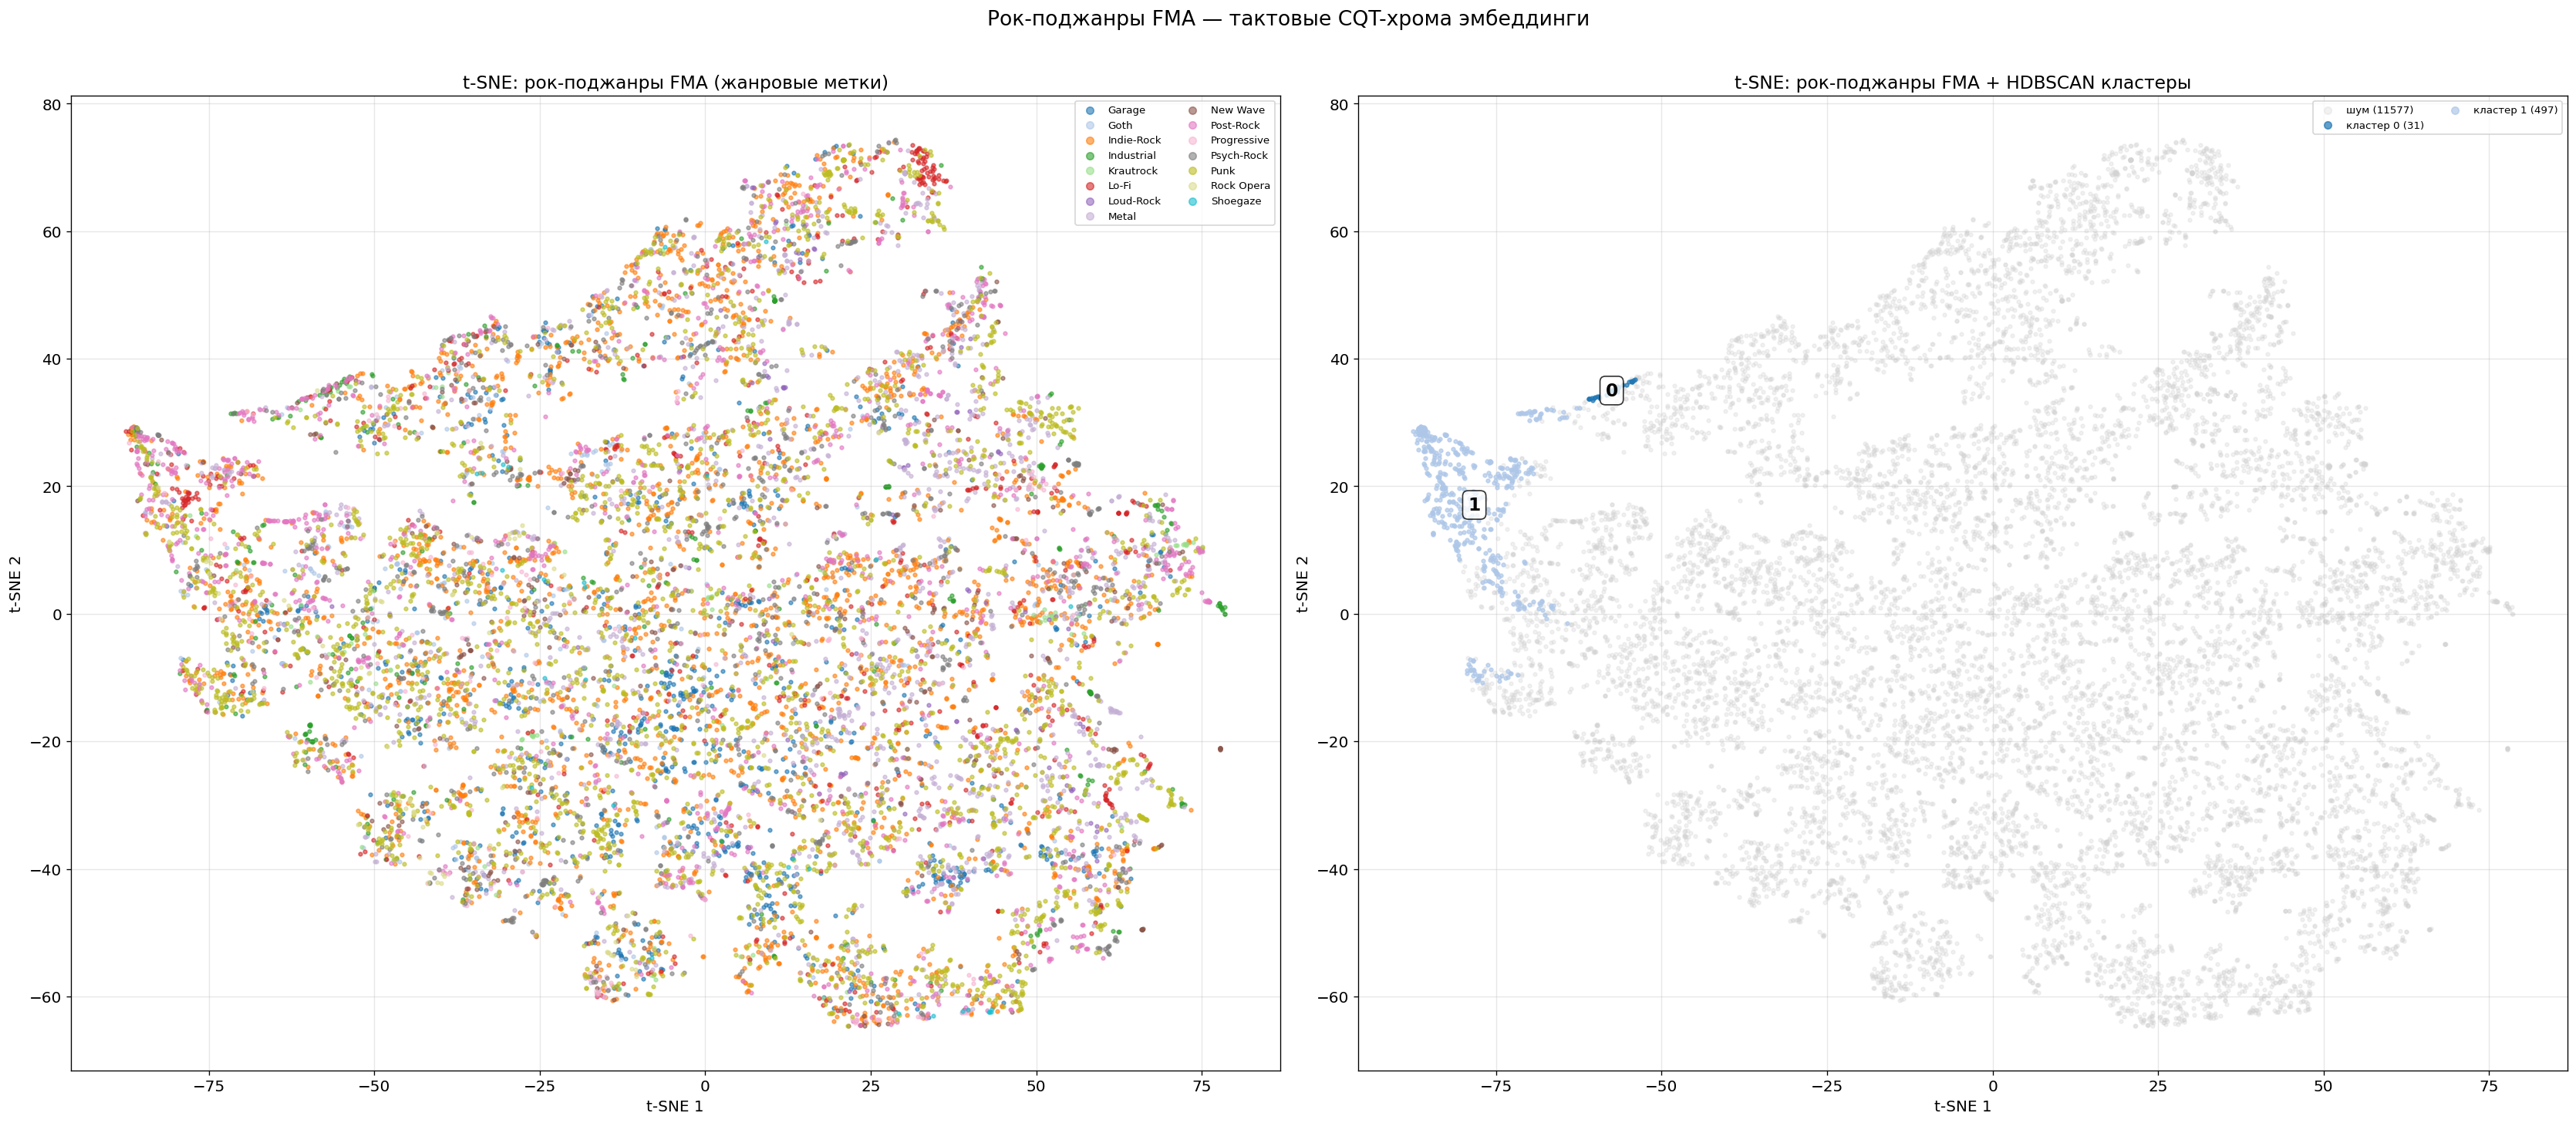

In [9]:
# Цвета для поджанров
unique_subgenres = sorted(set(labels_genre_name))
n_subgenres = len(unique_subgenres)
cmap_genres = plt.get_cmap('tab20') if n_subgenres <= 20 else plt.get_cmap('hsv')
subgenre_colors = {name: cmap_genres(i / n_subgenres) for i, name in enumerate(unique_subgenres)}

# Цвета для HDBSCAN-кластеров
cmap_clusters = plt.get_cmap('tab20')

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

# ─── Левый: по жанровым меткам ────────────────────────────────
for name in unique_subgenres:
    mask = labels_genre_name == name
    axes[0].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=8, alpha=0.6,
        color=subgenre_colors[name],
        label=name,
    )
axes[0].set_title('t-SNE: рок-поджанры FMA (жанровые метки)', fontsize=14)
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8, loc='best', ncol=2, markerscale=2)

# ─── Правый: HDBSCAN кластеры ─────────────────────────────────
for lab in sorted(unique_clusters):
    mask = cluster_labels == lab
    if lab == -1:
        color = 'lightgray'
        lbl = f'шум ({np.sum(mask)})'
        alpha = 0.3
        zorder = 1
    else:
        color = cmap_clusters(lab % 20)
        lbl = f'кластер {lab} ({np.sum(mask)})'
        alpha = 0.7
        zorder = 2
    axes[1].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=8, alpha=alpha,
        color=color, label=lbl,
        zorder=zorder,
    )

# Подписи центроидов
for lab in unique_clusters:
    if lab == -1:
        continue
    mask = cluster_labels == lab
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    axes[1].annotate(
        f'{lab}', (cx, cy),
        fontsize=14, fontweight='bold', ha='center', va='center',
        color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='black', alpha=0.8),
        zorder=10,
    )

axes[1].set_title('t-SNE: рок-поджанры FMA + HDBSCAN кластеры', fontsize=14)
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(alpha=0.3)
if len(unique_clusters) <= 25:
    axes[1].legend(fontsize=8, loc='best', ncol=2, markerscale=2)

fig.suptitle(
    'Рок-поджанры FMA — тактовые CQT-хрома эмбеддинги',
    fontsize=16, y=1.01,
)
plt.tight_layout()
plt.show()